In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose, STL

#EDA и визуализация данных (Netflix)

Задание 1
1) загружаем датасет

In [ ]:
df = pd.read_csv('netflix_titles.csv')

1)  Размер таблицы    
2)  список колонок
3)  типы данных

In [3]:
print(df.shape) #6234 столбцов и 12 колонок
print(list(df.columns))
print(df.dtypes) 

(6234, 12)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
show_id         int64
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


1.  Какие признаки числовые, какие категориальные?
2.  Какие колонки выглядят “грязными” или неоднозначными?

In [4]:
print(list(df.select_dtypes(include=['Int64']))) #числовы признаки
print(list(df.select_dtypes(include=['str']))) #категориялные признаки

['show_id', 'release_year']
['type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [5]:
print(df.isnull().sum()) 
#колонки director, cast, country достаточно загрезнены а так же есть некоторое пробелы в колонках date_added, rating

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64


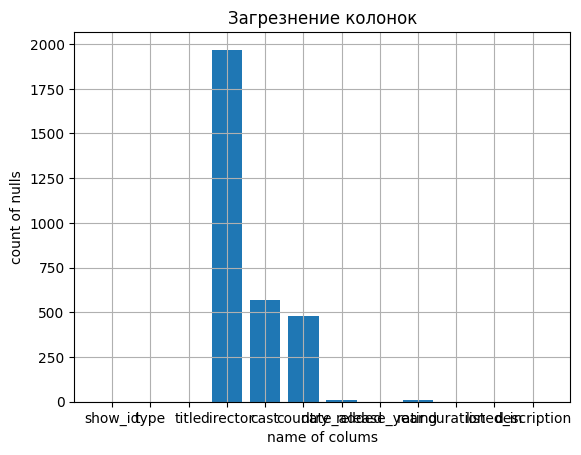

In [6]:
#визуализация
plt.bar(df.isnull().sum().keys(), df.isnull().sum().values)
plt.grid(alpha=1)
plt.title('Загрезнение колонок')
plt.xlabel('name of colums')
plt.ylabel('count of nulls')
plt.show()

Задание 2
1)  Соотношение фильмов и сериалов в каталоге
2)  Как менялось количество добавляемых на платформу тайтлов по годам  
3)  Отличается ли эта динамика для фильмов и сериалов?

4265
1969
68.4%
31.6%


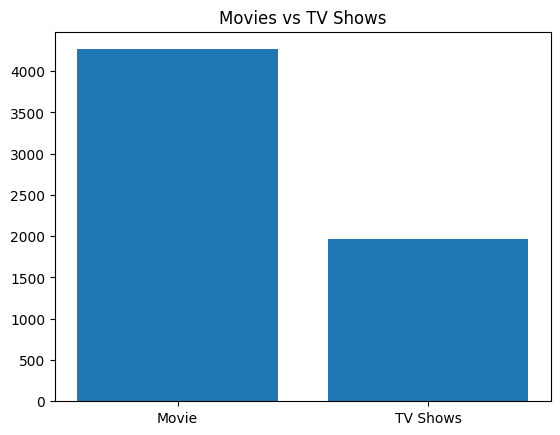

In [7]:
print(df[df['type'] == 'Movie'].shape[0]) #4265
print(df[df['type'] != "Movie"].shape[0]) #1969
#С процентами
print(str(round((df[df['type'] == 'Movie'].shape[0] * 100)/len(df), 1)) + "%") #68.4% movies
print(str(round((df[df['type'] != "Movie"].shape[0] *100)/len(df), 1)) + "%") #31.6% TV Shows
#Визуализация
plt.bar(["Movie", "TV Shows"], [df[df['type'] == 'Movie'].shape[0], df[df['type'] != "Movie"].shape[0]])
plt.title("Movies vs TV Shows")
plt.show()

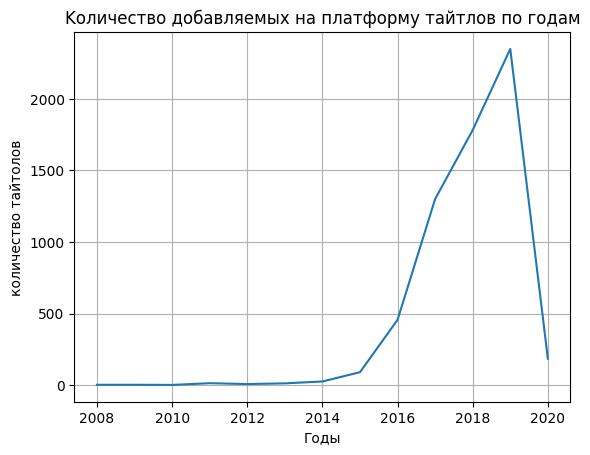

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
res = df['date_added'].dt.year.value_counts().sort_index(ascending=False)

#Визуализация
plt.plot(res.index, res.values)
plt.grid(alpha=1)
plt.title('Kоличество добавляемых на платформу тайтлов по годам')
plt.xlabel('Годы')
plt.ylabel('количество тайтолов')
plt.show()

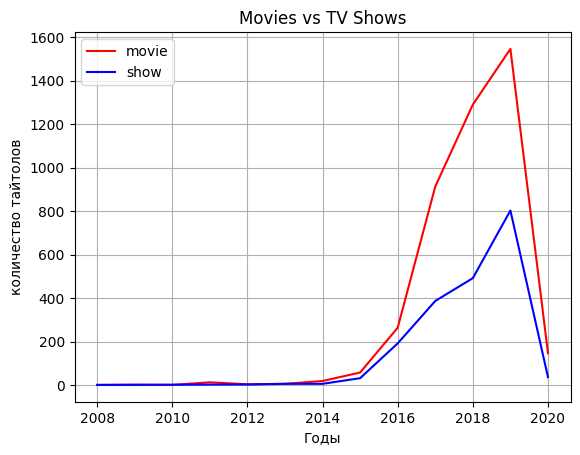

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
resm = df[df['type'] == "Movie"]['date_added'].dt.year.value_counts().sort_index(ascending=False)
ress = df[df['type'] != "Movie"]['date_added'].dt.year.value_counts().sort_index(ascending=False)

#Визуализация
plt.plot(resm.index, resm.values, color="red", label='movie')
plt.plot(ress.index, ress.values, color='blue', label='show')
plt.grid(alpha=1)
plt.legend()
plt.title("Movies vs TV Shows")
plt.xlabel('Годы')
plt.ylabel('количество тайтолов')
plt.show()

1)  Исходя из приведённых статистик мы можем сделать вывод, что фильмов больше, чем сериалов, чуть больше чем в два раза
2)  Исходя из графика мы можем чётко увидеть, что тайтлы начали добавляться активно с 2015 года, а пик добавлений составил 2019 год с рекордными показателями в 2349 тайтлов
3)  Исходя из последнего графика мы можем заметить, что общий этап развития не менялся, и после 2015 года фильмы держали некоторый отрыв от сериалов, но в начале они были одинаковы, и даже в одном году сериал всё же сумел собрать больше результатов, хоть и только на несколько тайтлов

Задание 3
1. Какие страны чаще всего встречаются как страны производства?
2. Насколько распределение стран неравномерно?
3. Какую долю всего контента дают топ-5 стран?

In [10]:
df.dropna(subset=['country'], inplace=True)
res = df['country'].str.split(', ').explode().str.strip(',').explode().value_counts()
print(res.head(5)) #United States': 2610, 'India': 838, 'United Kingdom': 602, 'Canada': 318, 'France': 271

country
United States     2610
India              838
United Kingdom     602
Canada             318
France             271
Name: count, dtype: int64


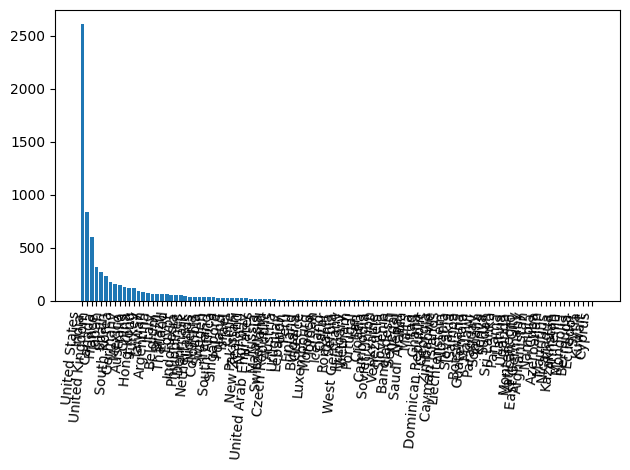

In [11]:
plt.bar(res.index, res.values)
plt.xticks(rotation=85, ha='right')
plt.tight_layout()
plt.show()

In [12]:
a = list(res.values)
top5 = sum(a[i] for i in range(5))
rest = sum(a) - top5
print(top5) #4639
print(str(round(top5*100/sum(a), 1)) + "%") #64.6%

4639
64.6%


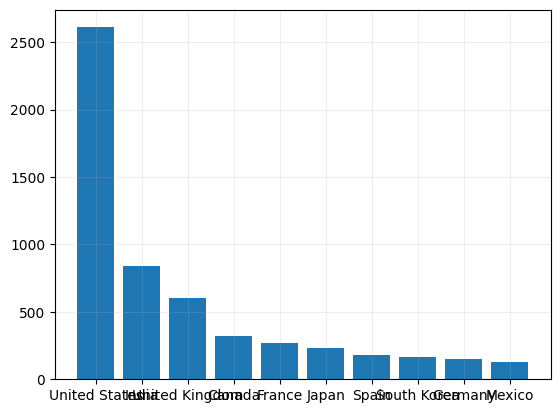

In [13]:
#топ-10 стран по количеству тайтлов.
name = list(res.index)[:10]
count = list(res.values)[:10]
plt.bar(name, count)
plt.grid(alpha=0.2)
plt.show()

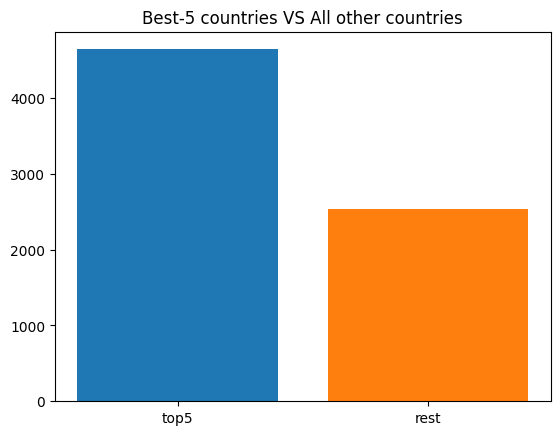

In [14]:
#топ-5 стран vs все остальные.
plt.bar('top5', top5)
plt.bar('rest', rest)
plt.title("Best-5 countries VS All other countries")
plt.show()

1)  Америка, Индия, Великобритания, Канада, Франция
2)  Через график мы можем отчётливо увидеть, что он имеет большой хвост, что явно указывает на неравномерное распределение данных. Иными словами, 80 процентов хвоста почти не оказывает влияния на глобальное изменение данных
3)  Доля топ-5 стран значительно превышает результат даже при сравнении с суммой остальных 105 стран. Если конкретнее — они занимают 64.6%

Задание 4
1. Какие жанры наиболее популярны?
2. Отличается ли распределение жанров для фильмов и сериалов?
3. Есть ли жанры, которые встречаются заметно реже остальных?

International Movies Dramas Comedies International TV Shows Documentaries


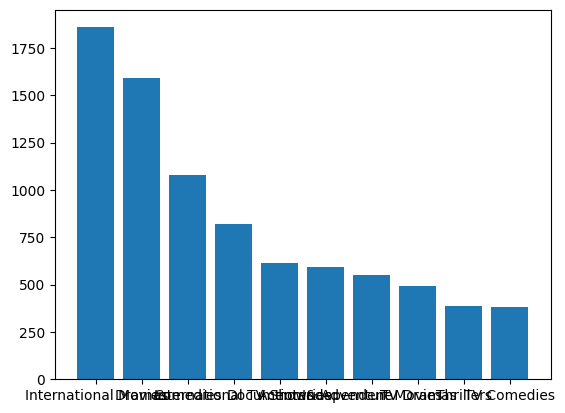

In [15]:
df.dropna(subset=['listed_in'], inplace=True)
res = df['listed_in'].str.split(', ').explode().str.strip(',').explode().value_counts()
print(*list(res.index)[:5])
#Топ 10 жанров
plt.bar(list(res.index)[:10], list(res.values)[:10])
plt.show()

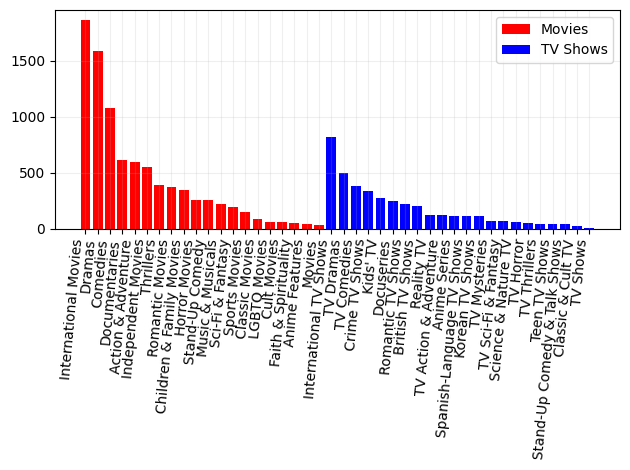

In [16]:
df.dropna(subset=['listed_in'], inplace=True)
resm = df[df['type'] == 'Movie']['listed_in'].str.split(', ').explode().str.strip(',').explode().value_counts()
ress = df[df['type'] != 'Movie']['listed_in'].str.split(', ').explode().str.strip(',').explode().value_counts()
plt.bar(resm.index, resm.values, color="red", label="Movies")
plt.bar(ress.index, ress.values, color="blue", label="TV Shows")
plt.grid(alpha=0.2)
plt.xticks(rotation=85, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

1)  Наиболее популярные жанры: International, Dramas, Comedies — причём они занимают первые 3 места и в сериалах, и в фильмах
2)  У них схожий тип распределения данных. Оба имеют несколько популярных жанров, которые влияют на общее количество сильнее, чем остальные вместе взятые. Другими словами, оба имеют длинный хвост. Но нельзя сказать, что они одинаковые. Например, в фильмах жанр Action & Adventure более популярен, чем в сериалах, а также есть жанр Independent, которого нет у сериалов. В то же время для сериалов более популярны жанры Kids и Anime, которые занимают более низкие места в топе фильмов.
3)  Как уже было отмечено, некоторые жанры используются очень мало: если конкретнее, для фильмов это последние 5 жанров, а для сериалов — последние 6

Задание 5
1. Какие возрастные рейтинги встречаются чаще всего?
2. Отличаются ли рейтинги у фильмов и сериалов?
3. Есть ли редкие или нестандартные рейтинги?

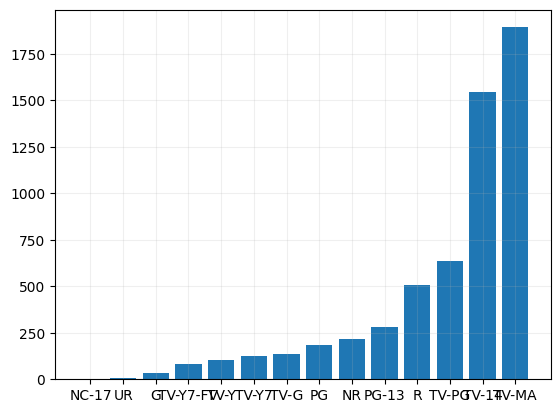

In [17]:
res = df.groupby('rating').size().sort_values()
plt.bar(res.index, res.values)
plt.grid(alpha=0.2)
plt.show()

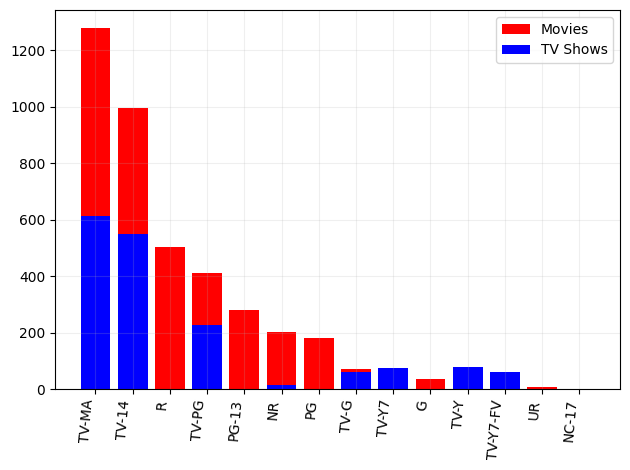

In [18]:
df.dropna(subset=['rating'], inplace=True)
resm = df[df['type'] == 'Movie'].groupby('rating').size().sort_values(ascending=False)
ress = df[df['type'] != 'Movie'].groupby('rating').size().sort_values(ascending=False)

plt.bar(resm.index, resm.values, color="red", label="Movies")
plt.bar(ress.index, ress.values, color="blue", label="TV Shows")
plt.grid(alpha=0.2)
plt.xticks(rotation=85, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

1)  Рейтинги TV-MA, TV-14, TV-PG являются самыми популярными
2)  Отличие между фильмами и сериалами в том, что, как и ожидалось, в сериалах больше произведений, охватывающих детскую аудиторию, тогда как взрослый контент относится преимущественно к фильмам.
3)  Редкие: G, NC-17, UR. Нестандартные: только для фильмов: R, PG-13, PG; только для сериалов: TV-Y, TV-Y7, TV-Y7-FV

Задание 6
1. Как распределена длительность фильмов?
2. Есть ли выбросы или странные значения?
3. Сколько сезонов обычно у сериалов?

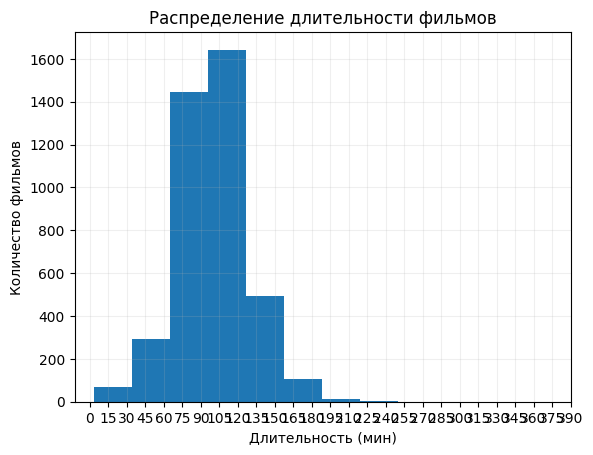

In [19]:
plt.hist([int(i.strip(' min')) for i in list(df[df['type'] == 'Movie']['duration'])])
plt.xlabel('Длительность (мин)')
plt.ylabel('Количество фильмов')
plt.title('Распределение длительности фильмов')
plt.xticks(range(0, 400, 15))
plt.grid(alpha=0.2)
plt.show()

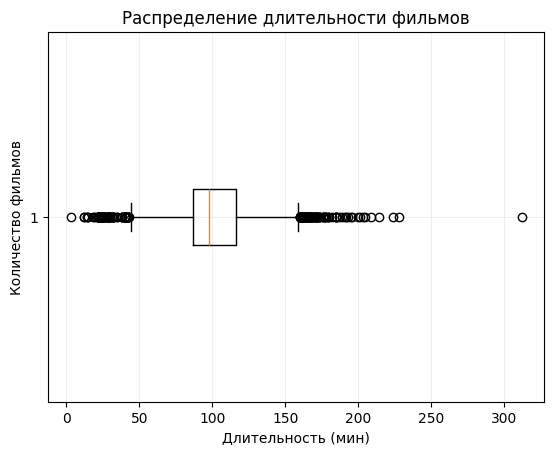

In [20]:
plt.boxplot([int(i.strip(' min')) for i in list(df[df['type'] == 'Movie']['duration'])], label="movies", vert=False)
plt.xlabel('Длительность (мин)')
plt.ylabel('Количество фильмов')
plt.title('Распределение длительности фильмов')
plt.grid(alpha=0.2)
plt.show()

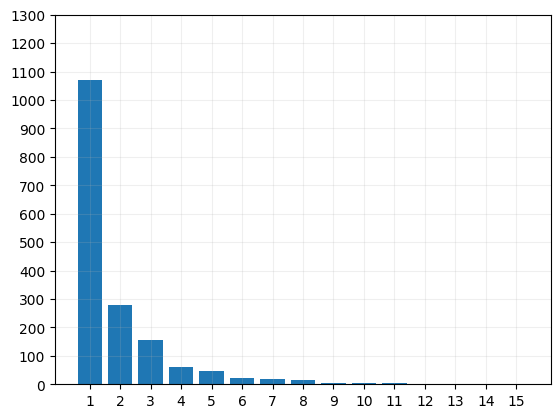

In [21]:
a = [int(i.strip(' Season')) for i in list(df[df['type'] != 'Movie']['duration'])]
d = {}
for i in range(len(a)):
    if a[i] not in d:
        d[a[i]] = 1
    else:
        d[a[i]] += 1

plt.bar(list(d.keys()), list(d.values()))
plt.xticks(range(1, 16))
plt.yticks(range(0, 1400, 100))
plt.grid(alpha=0.2)
plt.show()

1)  В основном фильмы располагаются в диапазоне от 95 до 125 минут, диапазон 65–95 также является достаточно популярным, а выше 125 и ниже 65 минут встречается значительно реже. Можно заметить интересную особенность — наличие аномальных данных в районе 300 минут, которые могут смещать среднее значение, поэтому рекомендуется использовать медиану при анализе
2)  Если посмотреть на результаты boxplot, можно заметить 230 аномальных значений, что составляет 5.42% от общего количества данных — предсказуемый результат без сюрпризов
3)  Обычно у сериалов 1 сезон, и вероятность того, что случайный сериал является односезонным, составляет 67%. При этом в графике нет неожиданных значений — иными словами, чем больше сезонов, тем меньше тайтлов: 67%, 15%, 8%, 3% и т.д.

Задание 7
1. Есть ли сезонность в добавлении контента на платформу?
2. В какие месяцы контент добавляется чаще всего?
3. Меняется ли эта сезонность со временем?

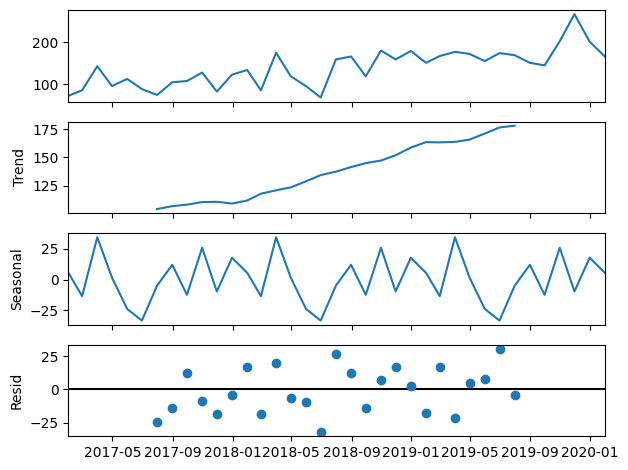

In [22]:
df = df.dropna(subset=['date_added'])
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df.set_index('date_added', inplace=True)
count = df.loc['2017':].resample('ME').size()
res = seasonal_decompose(count, model='additive', period=12)
res.plot()
plt.show()

In [23]:
stl = STL(count, period=12)
res_stl = stl.fit()
resid = res_stl.resid
seasonal = res_stl.seasonal
F_s = max(0, 1 - (resid.var() / (seasonal + resid).var()))
print(F_s)

0.7675131119503664


1)  Да, есть сильная сезонность — коэффициент показывает F_s = 0.79
2)  В 3-м месяце года, а именно в марте, сезонная составляющая увеличивается примерно на 25%, и в 10-м месяце года тоже заметен сезонный прогресс
3)  Нет, сезонность не менялась. Остаток стабильно держится около 1, что доказывает это

Задание 8
1)  3 самых интересных наблюдения,
2)  2 проблемы качества данных,
3)  1 идея, какую задачу можно было бы решать с помощью ML на этом датасете.

1)  Сериалы больше предназначены для детской аудитории, нежели фильмы
2)  Индия занимает 2-е место как страна производства, хотя популярных тайтлов у неё меньше, чем у Великобритании и других стран, что доказывает: индийские тайтлы рассчитаны прежде всего на жителей самой страны
3)  Пик добавления тайтлов пришёлся на 2019–2020 год, что может быть связано с началом пандемии коронавируса и закрытием кинотеатров

1)  Из-за того что тайтлы начали активно добавляться только после 2015 года, при расчёте статистики, например сезонности, эти данные могут сильно смещать среднее значение вниз
2)  Из-за того что жанры для фильмов и сериалов записаны отдельно, приведение их к единому виду для сравнения на одной оси X требует ручной очистки

1)  Предсказание listed_in с помощью title + cast + rating + description